In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from agents.q_learning import QLearningAgent
from environment.inventory_env import InventoryEnvironment

env = InventoryEnvironment()

info = env.get_state_space_info()

agent = QLearningAgent(
    info['n_states'],
    info['n_actions']
)

print("Working!")

[Environment] Loaded 731 days of data.
[Environment] Total unique states : 42
[Environment] Total actions        : 3
[Environment] Action space         : [0, 10, 20]
Working!


In [4]:
# Train the agent
rewards = agent.train(env, 2000)

print("Training completed!")

[Q-Learning] Episode 100/2000 | Reward: -235387.00 | Epsilon: 0.6058
[Q-Learning] Episode 200/2000 | Reward: -218732.00 | Epsilon: 0.3670
[Q-Learning] Episode 300/2000 | Reward: -223970.00 | Epsilon: 0.2223
[Q-Learning] Episode 400/2000 | Reward: -213427.00 | Epsilon: 0.1347
[Q-Learning] Episode 500/2000 | Reward: -203206.00 | Epsilon: 0.0816
[Q-Learning] Episode 600/2000 | Reward: -225520.00 | Epsilon: 0.0494
[Q-Learning] Episode 700/2000 | Reward: -189756.00 | Epsilon: 0.0299
[Q-Learning] Episode 800/2000 | Reward: -185890.00 | Epsilon: 0.0181
[Q-Learning] Episode 900/2000 | Reward: -190096.00 | Epsilon: 0.0110
[Q-Learning] Episode 1000/2000 | Reward: -185010.00 | Epsilon: 0.0100
[Q-Learning] Episode 1100/2000 | Reward: -197575.00 | Epsilon: 0.0100
[Q-Learning] Episode 1200/2000 | Reward: -193089.00 | Epsilon: 0.0100
[Q-Learning] Episode 1300/2000 | Reward: -185480.00 | Epsilon: 0.0100
[Q-Learning] Episode 1400/2000 | Reward: -189375.00 | Epsilon: 0.0100
[Q-Learning] Episode 1500/200

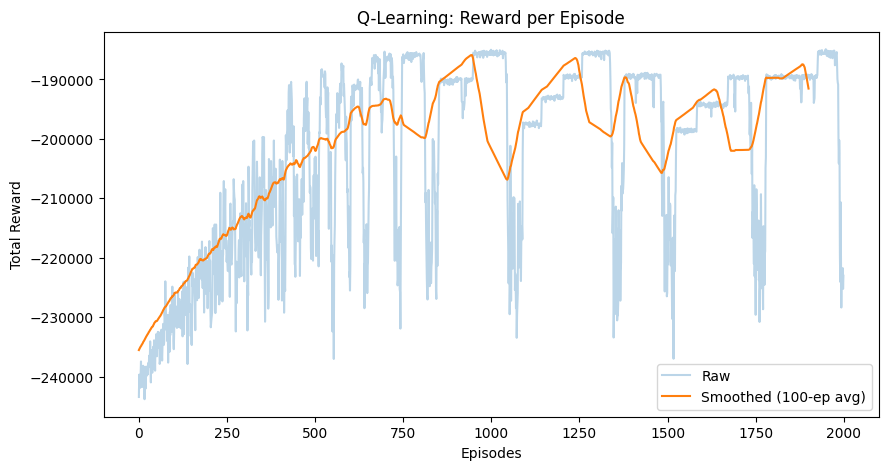

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Raw rewards
plt.plot(rewards, alpha=0.3, label="Raw")

# Smoothed rewards (100 episode average)
smoothed = np.convolve(rewards, np.ones(100)/100, mode='valid')
plt.plot(smoothed, label="Smoothed (100-ep avg)")

plt.title("Q-Learning: Reward per Episode")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.legend()

plt.savefig("../results/q_learning_reward.png")
plt.show()

In [7]:
plt.savefig("../results/q_learning_reward.png")

<Figure size 640x480 with 0 Axes>

In [9]:
results = agent.evaluate(env, 100)
print(results)

{'avg_reward': -213455.0, 'stockout_rate': 0.0, 'overstock_rate': 0.0}
